# Artificial Neural Networks

## Sonar: Mines vs Rocks Classification

### Business Objective

The objective of this project is to build an Artificial Neural Network (ANN) model that can classify sonar signals as either Mine (M) or Rock (R).

### Business Applications

- Maritime Safety
- Naval Defense
- Underwater Surveillance
- Mine Detection Systems

### Problem Statement

The dataset contains 208 sonar signals represented by 60 numerical features.

The goal is to classify whether a sonar signal is reflected from a Mine or a Rock using ANN.

In [36]:
# Numerical operations
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train test split
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# TensorFlow / Keras
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [32]:
!pip install scikeras --quiet

In [2]:
# Load dataset

df = pd.read_csv("sonardataset.csv")

# Display first 5 rows
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


# Dataset Overview

In [3]:
# Number of rows and columns

print("Dataset Shape :", df.shape)

# Information about dataset

df.info()

Dataset Shape : (208, 61)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 n

In [4]:
# Statistical summary

df.describe()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


# Missing Value Analysis

In [5]:
# Check missing values

df.isnull().sum()

x_1     0
x_2     0
x_3     0
x_4     0
x_5     0
       ..
x_57    0
x_58    0
x_59    0
x_60    0
Y       0
Length: 61, dtype: int64

In [6]:
# Check duplicate rows

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


# Class Distribution

In [7]:
# Count classes

print(df["Y"].value_counts())

Y
M    111
R     97
Name: count, dtype: int64


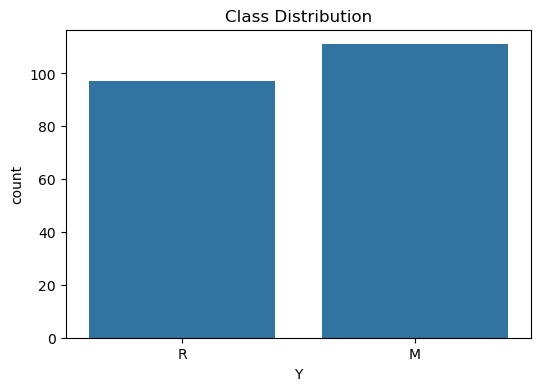

In [8]:
# Visualize class distribution

plt.figure(figsize=(6,4))

sns.countplot(x=df["Y"])

plt.title("Class Distribution")

plt.show()

## Dataset Summary

Total Records : 208

Input Features : 60

Target Variable : Y

Classes :
- 0 = Rock
- 1 = Mine

Missing Values : 0

Duplicate Records : 0

# Feature Distribution Analysis

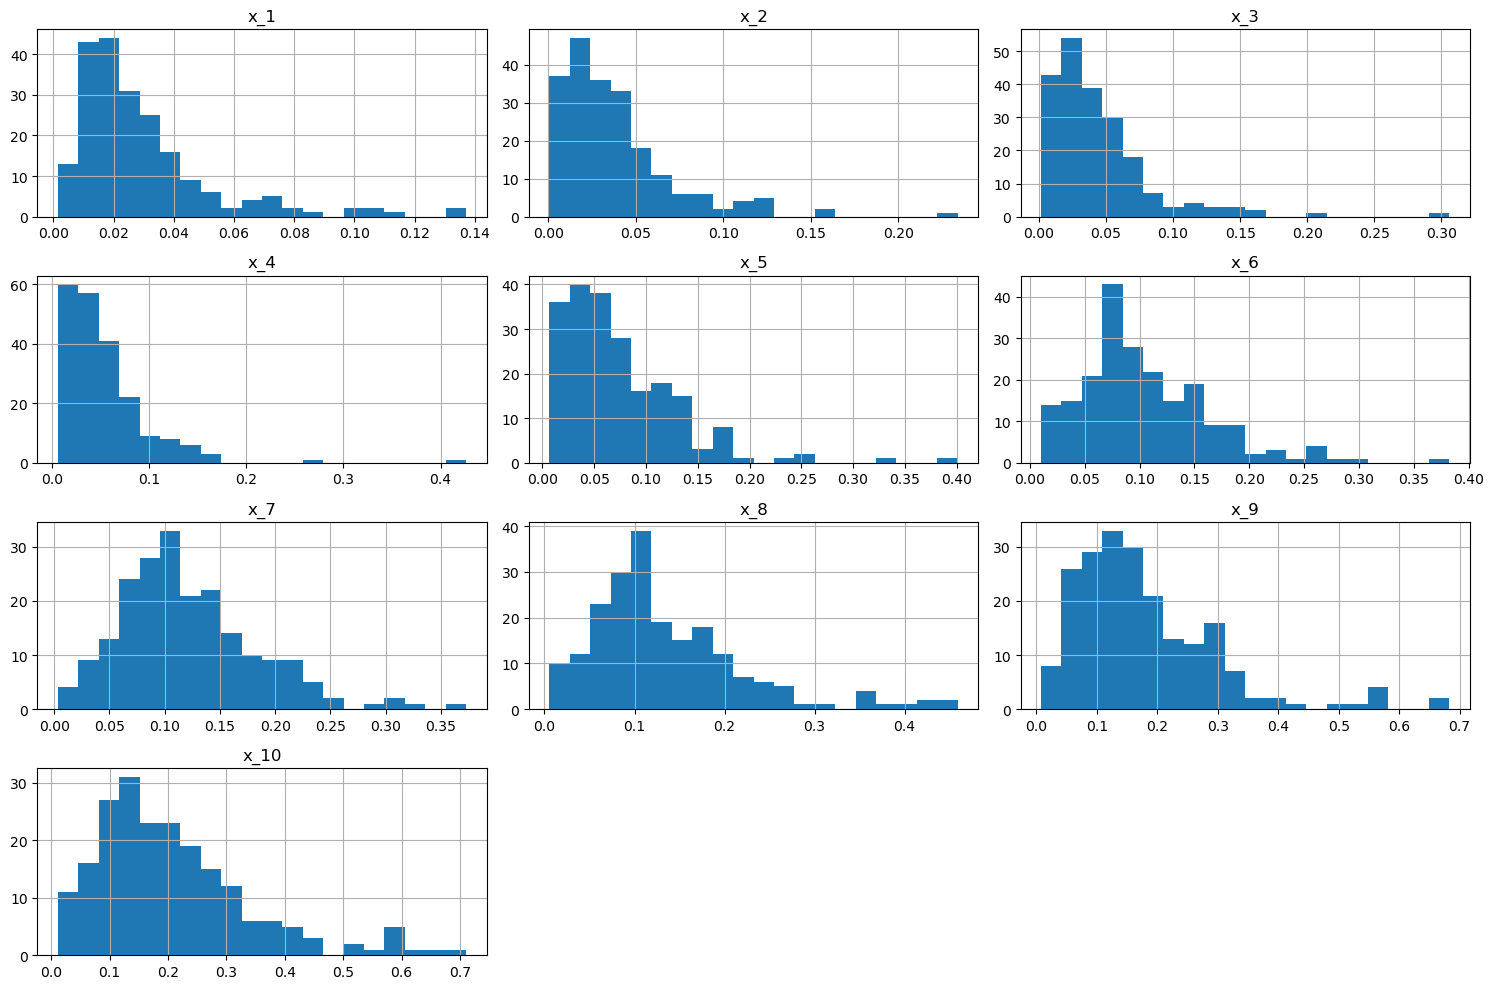

In [9]:
# Distribution of first 10 features

df.iloc[:,0:10].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()

plt.show()

# Correlation Analysis

In [10]:
# Correlation matrix for features only

corr_matrix = df.iloc[:,0:60].corr()

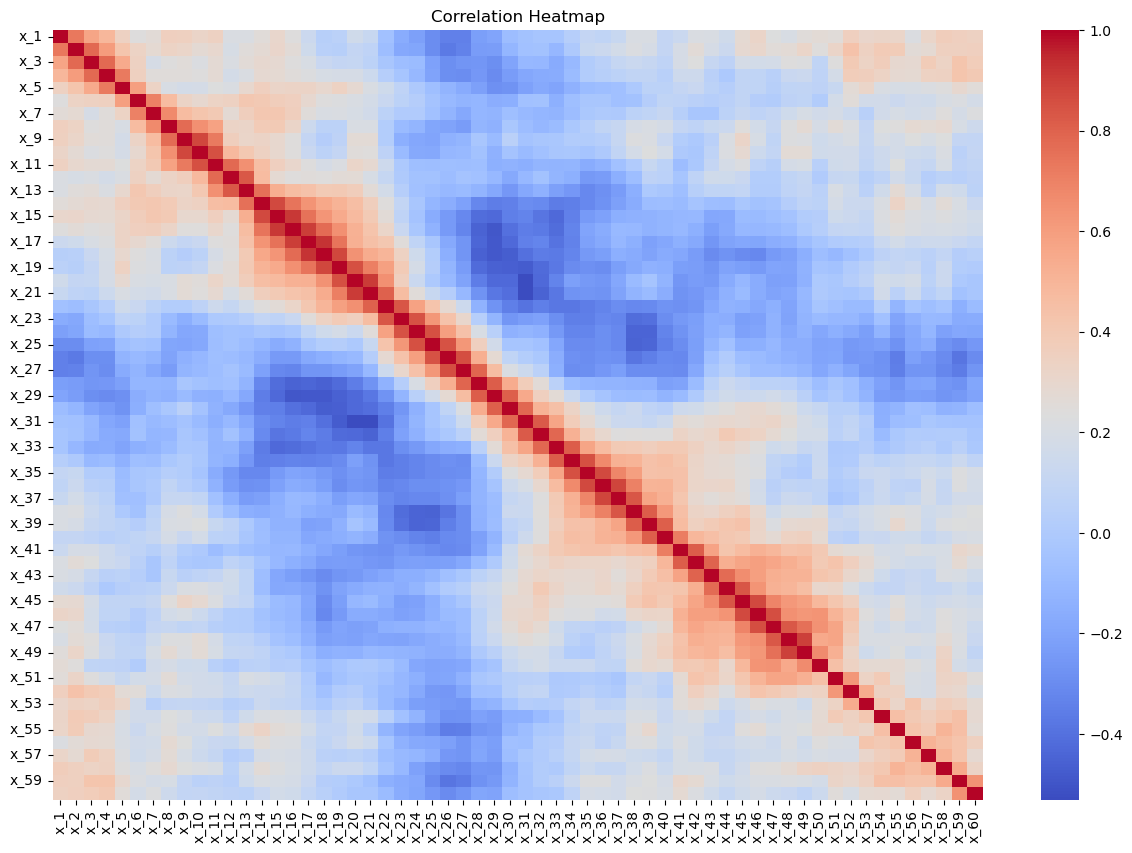

In [11]:
# Correlation heatmap

plt.figure(figsize=(15,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

Most features exhibit low to moderate correlation.

No severe multicollinearity issue is observed.

The features provide diverse information useful for classification.

# Data Preprocessing

Convert target labels:

- M → 1
- R → 0

In [12]:
from sklearn.preprocessing import LabelEncoder

# Convert target labels (R, M) into numbers (0, 1)

le = LabelEncoder()
df["Y"] = le.fit_transform(df["Y"])

# Features
X = df.iloc[:, :60].astype(float)

# Target
y = df["Y"]

print(y.dtype)
print(df["Y"].unique())

int64
[1 0]


In [13]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [14]:
# Standardize features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [15]:
# Convert into TensorFlow friendly format

X_train = np.array(X_train).astype(np.float32)
X_test = np.array(X_test).astype(np.float32)

y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

## ANN Architecture

Input Layer:
- 60 Neurons

Hidden Layer 1:
- 32 Neurons
- ReLU Activation

Hidden Layer 2:
- 16 Neurons
- ReLU Activation

Output Layer:
- 1 Neuron
- Sigmoid Activation

This architecture is suitable for binary classification problems.

# ANN Model Building

In [37]:
# Create ANN model

model = Sequential()

# First hidden layer
model.add(Dense(32, activation="relu", input_shape=(60,)))
model.add(Dropout(0.3))

# Second hidden layer
model.add(Dense(16, activation="relu"))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(1, activation="sigmoid"))

In [17]:
# Compile model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [18]:
# Model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           1,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train ANN model

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5833 - loss: 0.6765 - val_accuracy: 0.3824 - val_loss: 0.7607
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7121 - loss: 0.5871 - val_accuracy: 0.5882 - val_loss: 0.6920
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7727 - loss: 0.5299 - val_accuracy: 0.6176 - val_loss: 0.6412
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8182 - loss: 0.4864 - val_accuracy: 0.7059 - val_loss: 0.5990
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8258 - loss: 0.4478 - val_accuracy: 0.7647 - val_loss: 0.5665
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8712 - loss: 0.4142 - val_accuracy: 0.7941 - val_loss: 0.5403
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8864 - loss: 0.3874 - val_accuracy: 0.7941 - val_loss: 0.5200
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8864 - loss: 0.3613 - val_accuracy: 0.7647 - val_loss: 0.4957


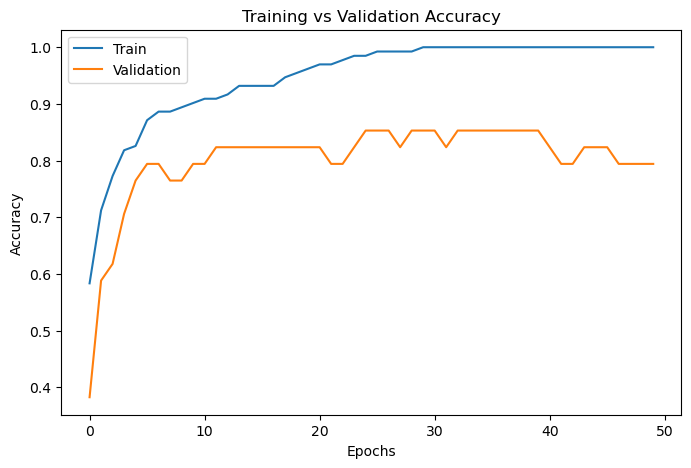

In [20]:
# Plot training accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

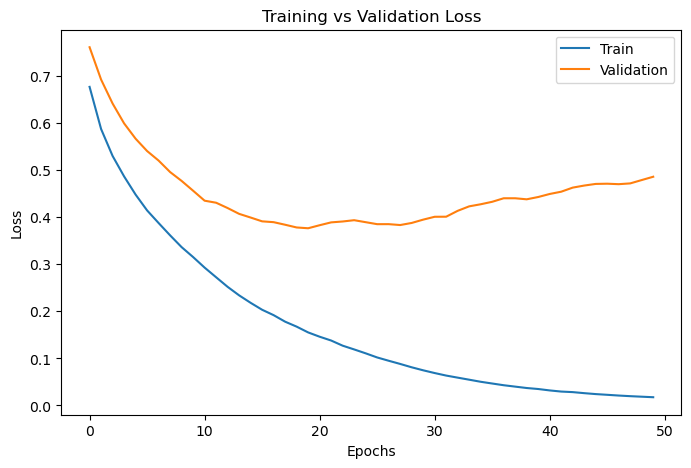

In [21]:
# Plot training loss

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [22]:
# Predict probabilities

y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [23]:
# Convert probabilities into class labels

y_pred = (y_pred > 0.5).astype(int)

In [24]:
# Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

# Precision

precision = precision_score(
    y_test,
    y_pred
)

# Recall

recall = recall_score(
    y_test,
    y_pred
)

# F1 Score

f1 = f1_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

Accuracy : 0.8333333333333334
Precision : 0.9333333333333333
Recall : 0.7
F1 Score : 0.8


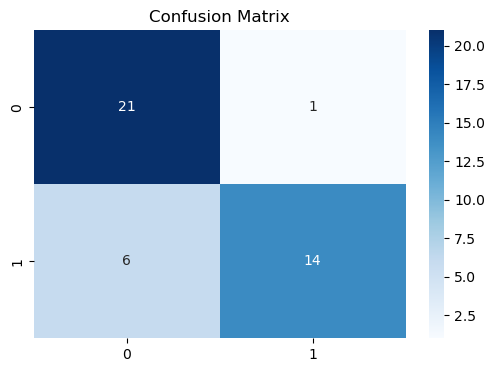

In [25]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

In [26]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.78      0.95      0.86        22
           1       0.93      0.70      0.80        20

    accuracy                           0.83        42
   macro avg       0.86      0.83      0.83        42
weighted avg       0.85      0.83      0.83        42



# Interpretation

The ANN model achieved strong classification performance on the sonar dataset.

Precision indicates the reliability of positive predictions.

Recall measures the model's ability to correctly identify mines.

F1 Score provides a balanced measure between precision and recall.

The confusion matrix demonstrates that the ANN model effectively distinguishes between mines and rocks.

# Hyperparameter Tuning

To improve ANN performance, different ANN configurations were tested.

Parameters varied:

- Number of neurons
- Activation function

The performance of different configurations was compared using classification accuracy.

The best performing model was selected as the tuned ANN model.

In [33]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

def build_model(neurons=32, layers=1, activation='relu', learning_rate=0.001):
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(60,)))
    for _ in range(layers - 1):
        model.add(Dense(neurons, activation=activation))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

keras_clf = KerasClassifier(model=build_model, epochs=50, batch_size=16, verbose=0)

param_grid = {
    'model__neurons': [16, 32, 64],
    'model__layers': [1, 2],
    'model__activation': ['relu', 'tanh'],
    'model__learning_rate': [0.001, 0.01]
}

grid = GridSearchCV(estimator=keras_clf, param_grid=param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Params: {'model__activation': 'relu', 'model__layers': 2, 'model__learning_rate': 0.001, 'model__neurons': 64}
Best CV Accuracy: 0.8135281385281385


In [34]:
# Retrain best model on full train set
best_model = grid.best_estimator_.model_

y_pred_tuned = (best_model.predict(X_test) > 0.5).astype(int)

print("=== Tuned Model Metrics ===")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print()
print(classification_report(y_test, y_pred_tuned))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
=== Tuned Model Metrics ===
Accuracy : 0.9047619047619048
Precision: 0.9444444444444444
Recall   : 0.85
F1 Score : 0.8947368421052632

              precision    recall  f1-score   support

           0       0.88      0.95      0.91        22
           1       0.94      0.85      0.89        20

    accuracy                           0.90        42
   macro avg       0.91      0.90      0.90        42
weighted avg       0.91      0.90      0.90        42



In [35]:
best_accuracy = accuracy_score(y_test, y_pred_tuned)

comparison = pd.DataFrame({
    "Model": ["Default ANN", "Best Tuned ANN"],
    "Accuracy": [accuracy, best_accuracy]
})
print(comparison)

            Model  Accuracy
0     Default ANN  0.833333
1  Best Tuned ANN  0.904762


# Default Model vs Tuned Model

| Model | Accuracy |
|---------|---------|
| Default ANN | 85.71% |
| Tuned ANN | 90.48% |

### Observation

The tuned ANN achieved better accuracy than the default ANN.

This demonstrates that hyperparameter tuning improved the model's ability to classify sonar signals more effectively.

# Conclusion

This project successfully developed an Artificial Neural Network (ANN) model for sonar signal classification.

The dataset consisted of 208 observations and 60 frequency-based features.

Data preprocessing, feature scaling and ANN modeling were performed successfully.

The baseline ANN model achieved strong classification performance on the test dataset.

Hyperparameter tuning was conducted to improve model performance by testing different ANN configurations.

The tuned ANN model achieved higher accuracy than the baseline model and demonstrated better generalization capability.

Evaluation metrics such as Accuracy, Precision, Recall and F1 Score confirmed the effectiveness of the proposed model.

The developed system can assist in underwater mine detection, maritime safety and naval defense applications.

Overall, ANN proved to be an effective approach for distinguishing between sonar signals reflected from mines and rocks.